**Lab Assignment - 3**

**Scikit-learn: Data Preprocessing and Model Performance Evaluation**

**Part A - Data Loading and Preprocessing with Scikit-learn**

In [1]:
# ============================================
# Task 1 - Load and Understand the Dataset
# ============================================

# Import required libraries
import pandas as pd
import numpy as np

# --------------------------------------------
# 1. Load the dataset
# --------------------------------------------

# If the CSV is in the same folder as your notebook:
df = pd.read_csv("hotel_bookings.csv")

# Display first 5 rows
print("First 5 rows of the dataset:")
display(df.head())


# --------------------------------------------
# 2. Check the shape of the dataset
# --------------------------------------------

print("\nShape of the dataset:")
print(df.shape)

# Shape gives:
# Number of rows, Number of columns


# --------------------------------------------
# 3. Dataset information
# --------------------------------------------

print("\nDataset Information:")
df.info()


# --------------------------------------------
# 4. Statistical description
# --------------------------------------------

print("\nStatistical Description:")
display(df.describe())


# --------------------------------------------
# 5. Check data types
# --------------------------------------------

print("\nData Types:")
print(df.dtypes)


# --------------------------------------------
# 6. Check class distribution of is_canceled
# --------------------------------------------

print("\nClass Distribution of 'is_canceled':")

# Number of observations in each class
print(df["is_canceled"].value_counts())

# Percentage distribution
print("\nPercentage Distribution:")
print(df["is_canceled"].value_counts(normalize=True) * 100)


# --------------------------------------------
# 7. Create target variable y
# --------------------------------------------

y = df["is_canceled"]

print("\nTarget variable y:")
print(y.head())


# --------------------------------------------
# 8. Create feature matrix X
# --------------------------------------------

# Remove the target column from the dataset
X = df.drop(columns=["is_canceled"])

print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)


# --------------------------------------------
# 9. Identify numerical columns
# --------------------------------------------

numerical_cols = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("\nNumerical Columns:")
print(numerical_cols)

print("\nNumber of numerical columns:", len(numerical_cols))


# --------------------------------------------
# 10. Identify categorical columns
# --------------------------------------------

categorical_cols = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("\nCategorical Columns:")
print(categorical_cols)

print("\nNumber of categorical columns:", len(categorical_cols))


# --------------------------------------------
# 11. Display summary of feature types
# --------------------------------------------

print("\nFeature Summary:")
print("Total features:", X.shape[1])
print("Numerical features:", len(numerical_cols))
print("Categorical features:", len(categorical_cols))

First 5 rows of the dataset:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03



Shape of the dataset:
(119390, 32)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies              

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000



Data Types:
hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                

**Task 2 : - Missing Values, Leakage, and Outliers**

Missing Value Summary:


,Missing Count,Missing Percentage
company,112593,94.306893
agent,16340,13.686238
country,488,0.408744
children,4,0.003350



Columns with more than 50% missing values:
['company']
company: 94.31% missing

Shape after handling highly-missing column:
(119390, 31)

Remaining missing values:


agent       16340
country       488
children        4
dtype: int64


Leakage columns being removed:
['reservation_status', 'reservation_status_date']

Shape after removing leakage columns:
(119390, 29)

Numerical columns:
['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']


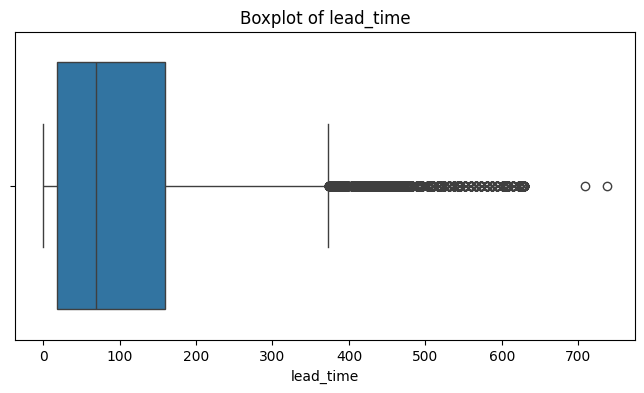

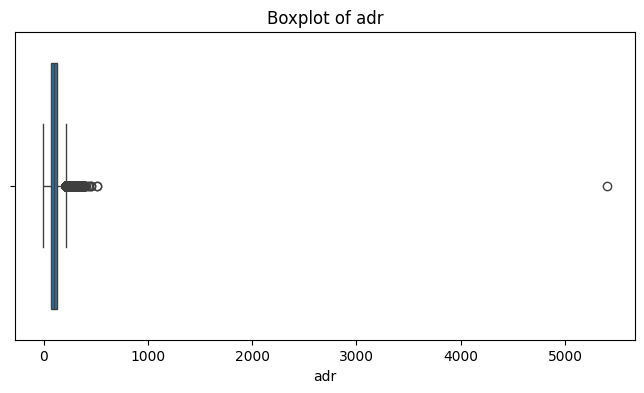

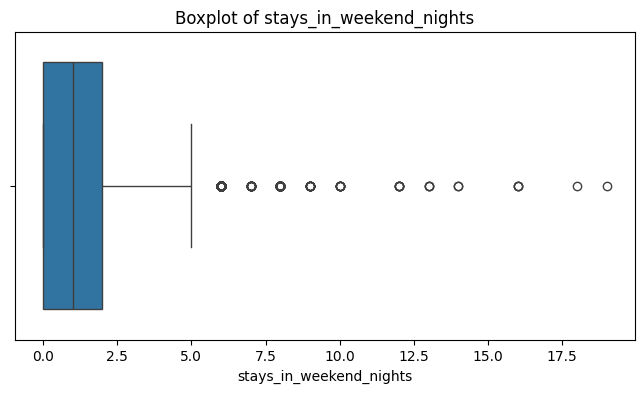

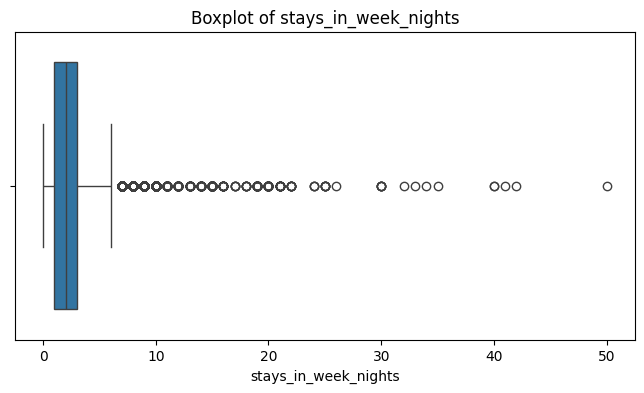

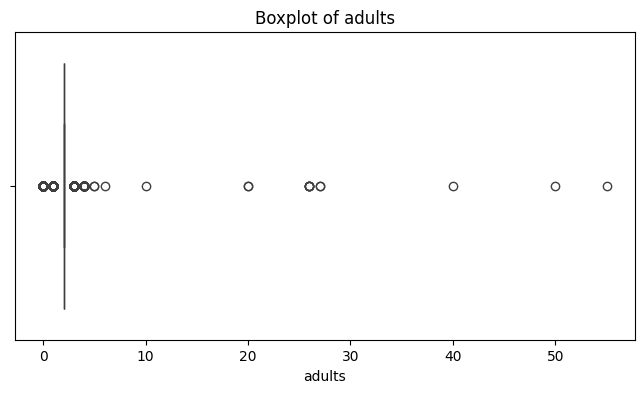

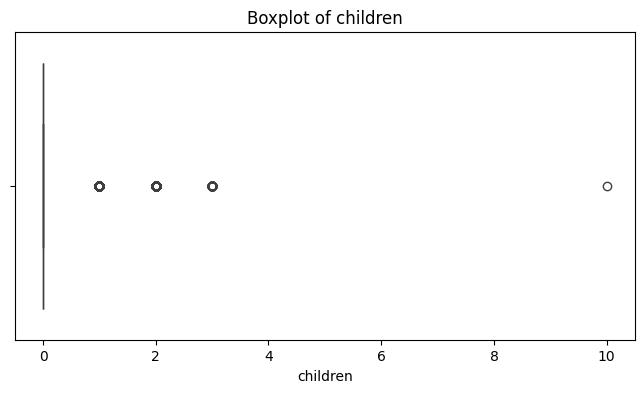

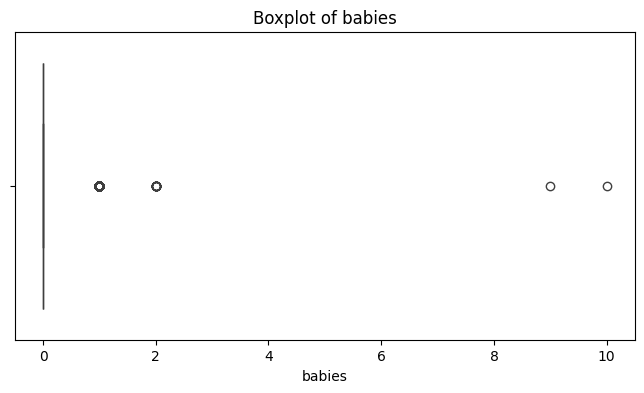

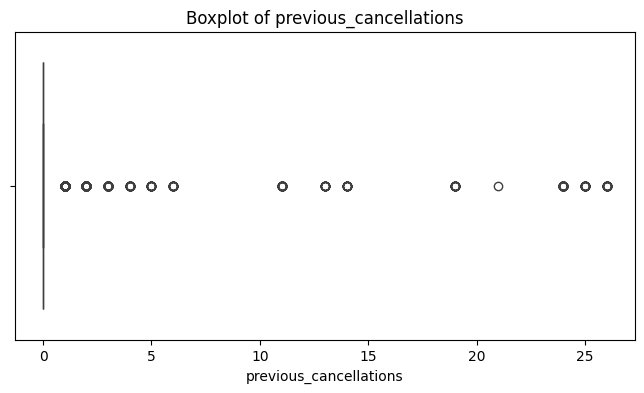

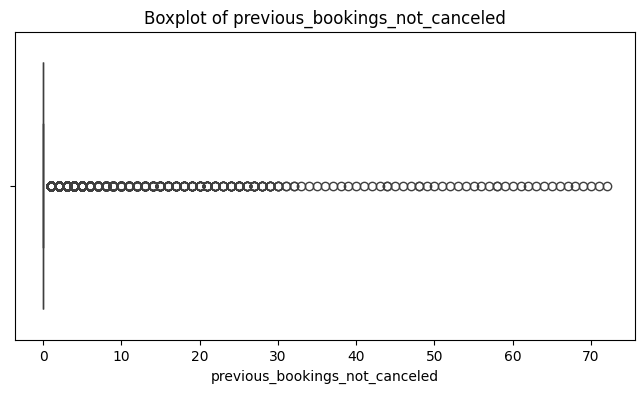

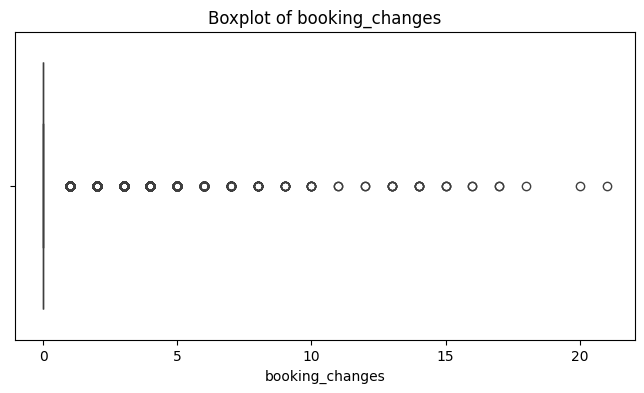

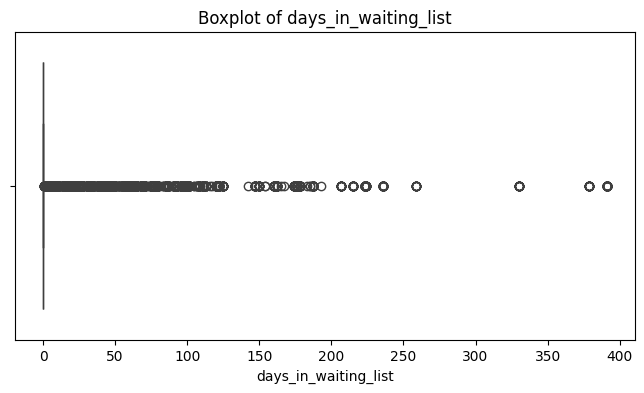

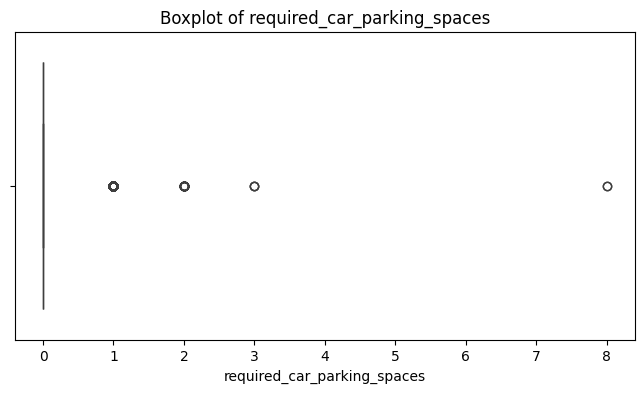

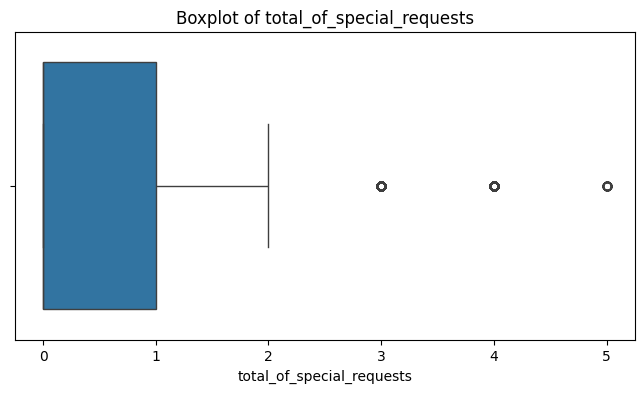


Outlier Summary:


,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
4,adults,2.00,2.0,0.00,2.000,2.000,29710,24.884831
9,booking_changes,0.00,0.0,0.00,0.000,0.000,18076,15.140297
5,children,0.00,0.0,0.00,0.000,0.000,8590,7.194907
11,required_car_parking_spaces,0.00,0.0,0.00,0.000,0.000,7416,6.211576
7,previous_cancellations,0.00,0.0,0.00,0.000,0.000,6484,5.430941
1,adr,69.29,126.0,56.71,-15.775,211.065,3793,3.176983
10,days_in_waiting_list,0.00,0.0,0.00,0.000,0.000,3698,3.097412
8,previous_bookings_not_canceled,0.00,0.0,0.00,0.000,0.000,3620,3.032080
3,stays_in_week_nights,1.00,3.0,2.00,-2.000,6.000,3354,2.809281
0,lead_time,18.00,160.0,142.00,-195.000,373.000,3005,2.516961



Rows before outlier/invalid-value removal: 119390
Rows after outlier/invalid-value removal: 118649
Total rows removed: 741
Percentage of rows removed: 0.62 %

Final dataset shape after Task 2:
(118649, 29)


In [2]:
# ============================================
# Task 2 - Missing Values, Leakage, and Outliers
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("hotel_bookings.csv")


# --------------------------------------------
# 1. Find missing-value count and percentage
# --------------------------------------------

missing_count = df.isnull().sum()

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

# Show only columns that contain missing values
missing_summary = missing_summary[
    missing_summary["Missing Count"] > 0
].sort_values(by="Missing Percentage", ascending=False)

print("Missing Value Summary:")
display(missing_summary)


# --------------------------------------------
# 2. Identify columns with very high missingness
# --------------------------------------------

# Define a threshold for very high missingness
high_missing_threshold = 50

high_missing_cols = missing_summary[
    missing_summary["Missing Percentage"] > high_missing_threshold
].index.tolist()

print("\nColumns with more than 50% missing values:")
print(high_missing_cols)

for col in high_missing_cols:
    print(
        f"{col}: "
        f"{missing_summary.loc[col, 'Missing Percentage']:.2f}% missing"
    )


# --------------------------------------------
# 3. Drop columns with very high missingness
# --------------------------------------------

# In the hotel bookings dataset, 'company' has a very high
# percentage of missing values (around 94%).
#
# It is dropped because the vast majority of observations
# do not contain company information. Keeping it would require
# extensive imputation and may not provide reliable information.

if "company" in df.columns:
    df = df.drop(columns=["company"])

print("\nShape after handling highly-missing column:")
print(df.shape)


# --------------------------------------------
# 4. Check missing values again
# --------------------------------------------

print("\nRemaining missing values:")
remaining_missing = df.isnull().sum()
remaining_missing = remaining_missing[
    remaining_missing > 0
].sort_values(ascending=False)

display(remaining_missing)


# --------------------------------------------
# 5. Remove data leakage columns
# --------------------------------------------

# These columns directly reveal the final outcome of the booking.
# They should NOT be used as input features for predicting
# 'is_canceled'.

leakage_columns = [
    "reservation_status",
    "reservation_status_date"
]

# Check which leakage columns actually exist
leakage_columns = [
    col for col in leakage_columns
    if col in df.columns
]

print("\nLeakage columns being removed:")
print(leakage_columns)

df = df.drop(columns=leakage_columns)

print("\nShape after removing leakage columns:")
print(df.shape)


# --------------------------------------------
# 6. Check numerical columns
# --------------------------------------------

numerical_cols = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("\nNumerical columns:")
print(numerical_cols)


# --------------------------------------------
# 7. Check selected numerical features for outliers
# --------------------------------------------

# Selected features from the hotel booking dataset.
# These are useful numerical variables where extreme
# observations can be inspected.

selected_num_cols = [
    "lead_time",
    "adr",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "booking_changes",
    "days_in_waiting_list",
    "required_car_parking_spaces",
    "total_of_special_requests"
]

# Keep only columns that exist in the dataset
selected_num_cols = [
    col for col in selected_num_cols
    if col in df.columns
]


# --------------------------------------------
# 8. Boxplots
# --------------------------------------------

for col in selected_num_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()


# --------------------------------------------
# 9. IQR method for detecting outliers
# --------------------------------------------

outlier_summary = []

for col in selected_num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    outlier_summary.append({
        "Column": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers),
        "Outlier Percentage": (len(outliers) / len(df)) * 100
    })

outlier_summary = pd.DataFrame(outlier_summary)

print("\nOutlier Summary:")
display(outlier_summary.sort_values(
    by="Outlier Count",
    ascending=False
))


# --------------------------------------------
# 10. Remove only clear/extreme outliers
# --------------------------------------------

# We should NOT blindly remove every IQR outlier.
# Hotel booking data can naturally contain large values,
# especially for lead_time and ADR.
#
# Here we apply reasonable domain-based limits to clearly
# unrealistic/extreme values.

rows_before = len(df)

# Clearly invalid values
if "adults" in df.columns:
    df = df[df["adults"] >= 1]

if "children" in df.columns:
    df = df[df["children"] >= 0]

if "babies" in df.columns:
    df = df[df["babies"] >= 0]

if "adr" in df.columns:
    # ADR should not be negative.
    df = df[df["adr"] >= 0]

if "lead_time" in df.columns:
    # Lead time cannot realistically be negative.
    df = df[df["lead_time"] >= 0]

if "stays_in_weekend_nights" in df.columns:
    df = df[df["stays_in_weekend_nights"] >= 0]

if "stays_in_week_nights" in df.columns:
    df = df[df["stays_in_week_nights"] >= 0]


# --------------------------------------------
# 11. Remove extreme ADR values using IQR
# --------------------------------------------

# ADR contains some extreme values.
# Use a conservative IQR rule rather than removing
# every outlier from every numerical feature.

if "adr" in df.columns:

    Q1 = df["adr"].quantile(0.25)
    Q3 = df["adr"].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 3 * IQR
    upper_bound = Q3 + 3 * IQR

    df = df[
        (df["adr"] >= lower_bound) &
        (df["adr"] <= upper_bound)
    ]


# --------------------------------------------
# 12. Report number of rows removed
# --------------------------------------------

rows_after = len(df)
rows_removed = rows_before - rows_after

print("\nRows before outlier/invalid-value removal:", rows_before)
print("Rows after outlier/invalid-value removal:", rows_after)
print("Total rows removed:", rows_removed)
print(
    "Percentage of rows removed:",
    round((rows_removed / rows_before) * 100, 2),
    "%"
)


# --------------------------------------------
# 13. Final dataset shape
# --------------------------------------------

print("\nFinal dataset shape after Task 2:")
print(df.shape)

**Task 3 - Create Two Preprocessing Pipelines**

In [3]:
# ============================================
# Task 3 - Create Two Preprocessing Pipelines
# ============================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


# --------------------------------------------
# 1. Define X and y
# --------------------------------------------

# Target variable
y = df["is_canceled"]

# Features
X = df.drop(columns=["is_canceled"])


print("X shape:", X.shape)
print("y shape:", y.shape)


# --------------------------------------------
# 2. Identify numerical and categorical columns
# --------------------------------------------

numerical_cols = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_cols = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()


print("\nNumerical columns:")
print(numerical_cols)

print("\nCategorical columns:")
print(categorical_cols)

print("\nNumber of numerical columns:", len(numerical_cols))
print("Number of categorical columns:", len(categorical_cols))


# --------------------------------------------
# 3. Train-Test Split
# --------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


print("\nTrain/Test Split:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


# Check class distribution after splitting
print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))


# ============================================
# 4. Numerical preprocessing - Pipeline A
# ============================================

numerical_pipeline_A = Pipeline(steps=[
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", StandardScaler())
])


# ============================================
# 5. Numerical preprocessing - Pipeline B
# ============================================

numerical_pipeline_B = Pipeline(steps=[
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", MinMaxScaler())
])


# ============================================
# 6. Categorical preprocessing
# ============================================

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])


# ============================================
# 7. ColumnTransformer - Pipeline A
# ============================================

preprocessor_A = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline_A, numerical_cols),
        ("cat", categorical_pipeline, categorical_cols)
    ]
)


# ============================================
# 8. ColumnTransformer - Pipeline B
# ============================================

preprocessor_B = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline_B, numerical_cols),
        ("cat", categorical_pipeline, categorical_cols)
    ]
)


# ============================================
# 9. Fit Pipeline A ONLY on training data
# ============================================

X_train_A = preprocessor_A.fit_transform(X_train)

# Transform test data using the already-fitted pipeline
X_test_A = preprocessor_A.transform(X_test)


print("\nPipeline A:")
print("X_train_A shape:", X_train_A.shape)
print("X_test_A shape :", X_test_A.shape)


# ============================================
# 10. Fit Pipeline B ONLY on training data
# ============================================

X_train_B = preprocessor_B.fit_transform(X_train)

# Transform test data using the already-fitted pipeline
X_test_B = preprocessor_B.transform(X_test)


print("\nPipeline B:")
print("X_train_B shape:", X_train_B.shape)
print("X_test_B shape :", X_test_B.shape)

X shape: (118649, 28)
y shape: (118649,)

Numerical columns:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Categorical columns:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']

Number of numerical columns: 18
Number of categorical columns: 10

Train/Test Split:
X_train: (94919, 28)
X_test : (23730, 28)
y_train: (94919,)
y_test : (23730,)

Training target distribution:
is_canceled
0    0.629126
1    0.370874
Name: proportion, dtype: float64

Testing target distribution:
is_canceled
0    0.629119
1    0.370881
Name: proportion, dtype: float64



**Part B - Model Training and Performance Evaluation**



**Task 4 - Train Two Classification Models**

In [4]:
# ============================================
# Task 4 - Train Two Classification Models
# ============================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline


# ============================================
# 1. Logistic Regression + Pipeline A
# ============================================

logistic_A = Pipeline(steps=[
    ("preprocessor", preprocessor_A),
    ("classifier", LogisticRegression(max_iter=1000))
])

# Train the model
logistic_A.fit(X_train, y_train)

print("Logistic Regression + Pipeline A trained successfully.")


# ============================================
# 2. Logistic Regression + Pipeline B
# ============================================

logistic_B = Pipeline(steps=[
    ("preprocessor", preprocessor_B),
    ("classifier", LogisticRegression(max_iter=1000))
])

# Train the model
logistic_B.fit(X_train, y_train)

print("Logistic Regression + Pipeline B trained successfully.")


# ============================================
# 3. Decision Tree + Pipeline A
# ============================================

tree_A = Pipeline(steps=[
    ("preprocessor", preprocessor_A),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

# Train the model
tree_A.fit(X_train, y_train)

print("Decision Tree + Pipeline A trained successfully.")


# ============================================
# 4. Decision Tree + Pipeline B
# ============================================

tree_B = Pipeline(steps=[
    ("preprocessor", preprocessor_B),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

# Train the model
tree_B.fit(X_train, y_train)

print("Decision Tree + Pipeline B trained successfully.")


# ============================================
# 5. Store all four models
# ============================================

models = {
    "Logistic Regression + StandardScaler": logistic_A,
    "Logistic Regression + MinMaxScaler": logistic_B,
    "Decision Tree + StandardScaler": tree_A,
    "Decision Tree + MinMaxScaler": tree_B
}

print("\nTotal trained models:", len(models))

for name in models:
    print("-", name)

Logistic Regression + Pipeline A trained successfully.
Logistic Regression + Pipeline B trained successfully.
Decision Tree + Pipeline A trained successfully.
Decision Tree + Pipeline B trained successfully.

Total trained models: 4
- Logistic Regression + StandardScaler
- Logistic Regression + MinMaxScaler
- Decision Tree + StandardScaler
- Decision Tree + MinMaxScaler


**Task 5 - Evaluate and Compare the Four Results**

In [5]:
# ============================================
# Task 5 - Evaluate and Compare the Four Models
# ============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import pandas as pd
import matplotlib.pyplot as plt


# ============================================
# 1. Evaluate all four models
# ============================================

results = []

for name, model in models.items():

    # Predictions on training data
    y_train_pred = model.predict(X_train)

    # Predictions on testing data
    y_test_pred = model.predict(X_test)

    # Training accuracy
    train_accuracy = accuracy_score(
        y_train,
        y_train_pred
    )

    # Testing accuracy
    test_accuracy = accuracy_score(
        y_test,
        y_test_pred
    )

    # Precision
    precision = precision_score(
        y_test,
        y_test_pred,
        zero_division=0
    )

    # Recall
    recall = recall_score(
        y_test,
        y_test_pred,
        zero_division=0
    )

    # F1-score
    f1 = f1_score(
        y_test,
        y_test_pred,
        zero_division=0
    )

    # Difference between training and testing accuracy
    accuracy_difference = train_accuracy - test_accuracy

    # Store results
    results.append({
        "Model": name,
        "Training Accuracy": train_accuracy,
        "Testing Accuracy": test_accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Train-Test Accuracy Difference": accuracy_difference
    })


# ============================================
# 2. Create final comparison table
# ============================================

results_df = pd.DataFrame(results)

# Sort by testing F1-score
results_df = results_df.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)


print("Final Model Comparison:")
display(results_df.round(4))

Final Model Comparison:


,Model,Training Accuracy,Testing Accuracy,Precision,Recall,F1-Score,Train-Test Accuracy Difference
0,Decision Tree + MinMaxScaler,0.9960,0.8621,0.8095,0.8216,0.8155,0.1339
1,Decision Tree + StandardScaler,0.9960,0.8620,0.8089,0.8222,0.8155,0.1340
2,Logistic Regression + StandardScaler,0.8191,0.8148,0.8045,0.6613,0.7259,0.0043
3,Logistic Regression + MinMaxScaler,0.8142,0.8110,0.8026,0.6502,0.7184,0.0033


**Find the best Logistic Regression and Decision Tree**

In [6]:
# ============================================
# 3. Find best Logistic Regression result
# ============================================

logistic_results = results_df[
    results_df["Model"].str.startswith("Logistic Regression")
]

best_logistic_name = logistic_results.iloc[0]["Model"]

best_logistic_model = models[best_logistic_name]

print("Best Logistic Regression:")
print(best_logistic_name)
print(
    "Test F1-Score:",
    round(logistic_results.iloc[0]["F1-Score"], 4)
)


# ============================================
# 4. Find best Decision Tree result
# ============================================

tree_results = results_df[
    results_df["Model"].str.startswith("Decision Tree")
]

best_tree_name = tree_results.iloc[0]["Model"]

best_tree_model = models[best_tree_name]

print("\nBest Decision Tree:")
print(best_tree_name)
print(
    "Test F1-Score:",
    round(tree_results.iloc[0]["F1-Score"], 4)
)

Best Logistic Regression:
Logistic Regression + StandardScaler
Test F1-Score: 0.7259

Best Decision Tree:
Decision Tree + MinMaxScaler
Test F1-Score: 0.8155


**Confusion Matrix — Best Logistic Regression**

Confusion Matrix - Logistic Regression + StandardScaler
[[13515  1414]
 [ 2981  5820]]


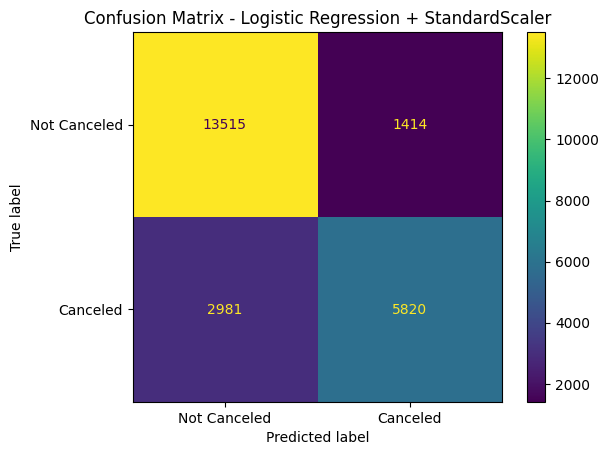

In [7]:
# ============================================
# 5. Confusion Matrix - Best Logistic Regression
# ============================================

y_pred_logistic = best_logistic_model.predict(X_test)

cm_logistic = confusion_matrix(
    y_test,
    y_pred_logistic
)

print("Confusion Matrix -", best_logistic_name)
print(cm_logistic)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=["Not Canceled", "Canceled"]
)

disp.plot()
plt.title(f"Confusion Matrix - {best_logistic_name}")
plt.show()

**Confusion Matrix — Best Decision Tree**

Confusion Matrix - Decision Tree + MinMaxScaler
[[13227  1702]
 [ 1570  7231]]


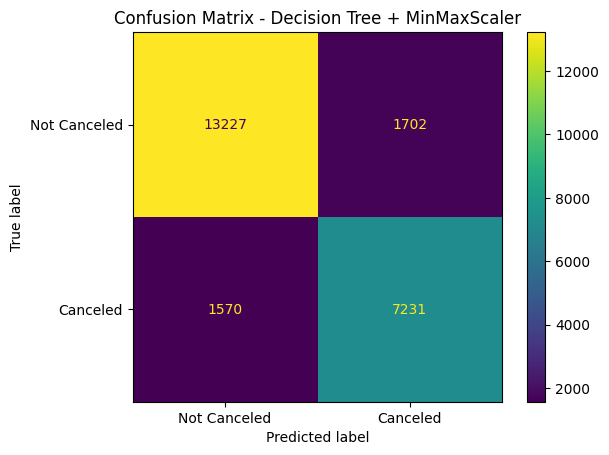

In [8]:
# ============================================
# 6. Confusion Matrix - Best Decision Tree
# ============================================

y_pred_tree = best_tree_model.predict(X_test)

cm_tree = confusion_matrix(
    y_test,
    y_pred_tree
)

print("Confusion Matrix -", best_tree_name)
print(cm_tree)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tree,
    display_labels=["Not Canceled", "Canceled"]
)

disp.plot()
plt.title(f"Confusion Matrix - {best_tree_name}")
plt.show()

**Check for Overfitting**

In [9]:
# ============================================
# 7. Overfitting Analysis
# ============================================

print("\nOverfitting Analysis:\n")

for _, row in results_df.iterrows():

    difference = row["Train-Test Accuracy Difference"]

    print(row["Model"])
    print(
        "Training Accuracy:",
        round(row["Training Accuracy"], 4)
    )
    print(
        "Testing Accuracy:",
        round(row["Testing Accuracy"], 4)
    )
    print(
        "Train-Test Difference:",
        round(difference, 4)
    )

    if difference < 0.05:
        print("Interpretation: Low evidence of overfitting.\n")

    elif difference < 0.10:
        print("Interpretation: Some evidence of overfitting.\n")

    else:
        print("Interpretation: Strong evidence of overfitting.\n")


Overfitting Analysis:

Decision Tree + MinMaxScaler
Training Accuracy: 0.996
Testing Accuracy: 0.8621
Train-Test Difference: 0.1339
Interpretation: Strong evidence of overfitting.

Decision Tree + StandardScaler
Training Accuracy: 0.996
Testing Accuracy: 0.862
Train-Test Difference: 0.134
Interpretation: Strong evidence of overfitting.

Logistic Regression + StandardScaler
Training Accuracy: 0.8191
Testing Accuracy: 0.8148
Train-Test Difference: 0.0043
Interpretation: Low evidence of overfitting.

Logistic Regression + MinMaxScaler
Training Accuracy: 0.8142
Testing Accuracy: 0.811
Train-Test Difference: 0.0033
Interpretation: Low evidence of overfitting.



In [10]:
# Optional: percentage-formatted comparison table

comparison_display = results_df.copy()

metric_columns = [
    "Training Accuracy",
    "Testing Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "Train-Test Accuracy Difference"
]

for col in metric_columns:
    comparison_display[col] = (
        comparison_display[col] * 100
    ).round(2).astype(str) + "%"

display(comparison_display)

,Model,Training Accuracy,Testing Accuracy,Precision,Recall,F1-Score,Train-Test Accuracy Difference
0,Decision Tree + MinMaxScaler,99.6%,86.21%,80.95%,82.16%,81.55%,13.39%
1,Decision Tree + StandardScaler,99.6%,86.2%,80.89%,82.22%,81.55%,13.4%
2,Logistic Regression + StandardScaler,81.91%,81.48%,80.45%,66.13%,72.59%,0.43%
3,Logistic Regression + MinMaxScaler,81.42%,81.1%,80.26%,65.02%,71.84%,0.33%


**Task 6 — Final Observations**

1. Which preprocessing-model combination gives the best overall result?

   The Decision Tree + MinMaxScaler combination gives the best overall result based on the highest testing F1-score of 0.8155 and the highest testing accuracy of 0.8621.

   However, the Decision Tree shows a large train-test accuracy gap of 0.1339, indicating strong overfitting. Therefore, while it has the best predictive performance among the four experiments, its generalization is less stable than Logistic Regression.

2. Does StandardScaler or MinMaxScaler affect Logistic Regression more?

   Yes. Logistic Regression is somewhat affected by the choice of scaler.

| Logistic Regression | Test Accuracy | F1-Score |
|---|---:|---:|
| StandardScaler | 0.8148 | **0.7259** |
| MinMaxScaler | 0.8110 | **0.7184** |

   StandardScaler performs slightly better:

   Accuracy improves by 0.0038 (0.38 percentage points).
   F1-score improves by 0.0075 (0.75 percentage points).

   Therefore, in this experiment, StandardScaler gives Logistic Regression a small performance advantage over MinMaxScaler.

3. Does scaling make a major difference for the Decision Tree?

   No. Scaling makes almost no difference to the Decision Tree.

| Decision Tree | Test Accuracy | F1-Score |
|---|---:|---:|
| StandardScaler | 0.8620 | 0.8155 |
| MinMaxScaler | 0.8621 | 0.8155 |

   The results are almost identical. The F1-score is exactly the same at 0.8155, while testing accuracy differs by only 0.0001.

   This is expected because Decision Trees make decisions based on feature thresholds and are generally not sensitive to the scale of numerical features.

4. Short Observations :

- Decision Tree + MinMaxScaler produced the best overall test performance, achieving 86.21% testing accuracy and an F1-score of 0.8155.

- Decision Tree models showed strong overfitting, with training accuracy of 99.60% compared with approximately 86.20% testing accuracy, giving a train-test gap of about 13.4 percentage points.

- Logistic Regression showed much less overfitting. The StandardScaler version had a training accuracy of 81.91% and testing accuracy of 81.48%, resulting in only a 0.43 percentage-point difference.

- StandardScaler performed slightly better than MinMaxScaler for Logistic Regression. Its F1-score was 0.7259, compared with 0.7184 for MinMaxScaler.

- Scaling had virtually no effect on the Decision Tree. Both scaling methods produced an F1-score of 0.8155, confirming that Decision Trees are largely insensitive to feature scaling.